In [18]:
!pip install nbformat

In [1]:
import PyCrystalField as cef

 *******************************************************
 *                PyCrystalField 2.3.11               *
 *  Please cite  J. Appl. Cryst. (2021). 54, 356-362   * 
 *    <https://doi.org/10.1107/S160057672001554X>      *
 *******************************************************



In [2]:
CeIn3Lig, Ce = cef.importCIF(
    "CeIn3.cif",
    mag_ion="Ce0"   # not Ce0 if your manual CIF labels it Ce1
    # CoordinationNumber=12,
    # Zaxis=[0, 0, 1],
    # Yaxis=[0, 1, 0],
    
)

unit cell: 4.70762 4.70762 4.70762 90.0 90.0 90.0
Importing atoms
   4 atoms added
.cif import complete.
Central ion: Ce at [0.0, 0.0, 0.0]
    AAAH! There is a super-close atom. Removing it...
 Nearest ligand: In
   Identified 12 In ligands.
    No mirror planes and no rotations in point group: ['x, y, z']
	Found a near-4-fold axis...  CSM= 1.6618602737682435e-31
    No charges found in cif file... guessing the In ligands are charged -2 ,
       and assuming the central ion has a 3+ charge: Ce3+

  Axes for point charge model (in ABC space):
        X axis = [ 2.24176514e-33 -1.00000000e+00 -1.75761685e-32] 
        Y axis = [ 1.00000000e+00  2.24176514e-33 -2.24176514e-33] 
        Z axis = [ 2.24176514e-33 -1.75761685e-32  1.00000000e+00] 

        we must inlcude the -m terms, and the eigenkets will be complex.

   Creating a point charge model...
B_2 -2  =  0.0
B_2 -1  =  0.0
B_2 0  =  -0.0
B_2 1  =  0.0
B_2 2  =  -0.0
B_4 -4  =  -0.0
B_4 -3  =  -0.0
B_4 -2  =  -0.0
B_4 -1  =  -0.

In [3]:
print(Ce.B)

[np.float64(-0.0411726599336256), np.float64(-0.205863299668129)]


Pseudo-critical field from max d<Sz>/dEb:
Eb* = 1.000050
Peak d<Sz>/dEb = 0.318325

Weighted crossover estimate:
Eb* = 1.650757 ± 0.533793

FWHM crossover estimate:
Eb* = 1.240562 ± 0.240512
FWHM range: [1.000050, 1.481074]


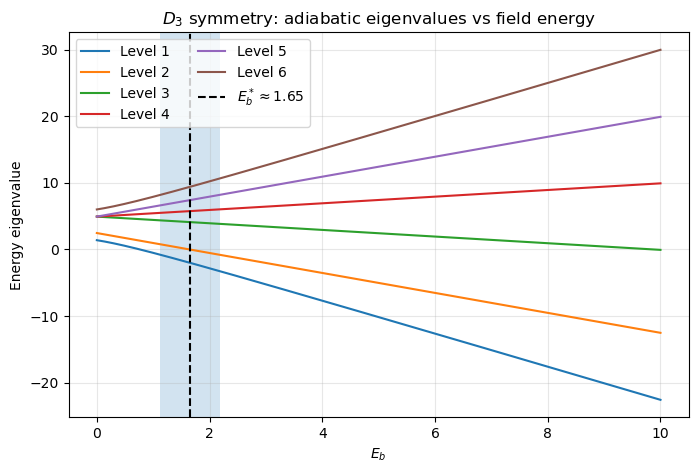

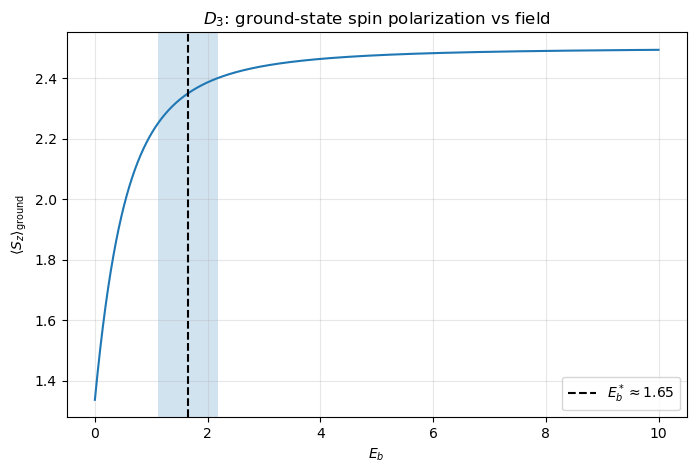

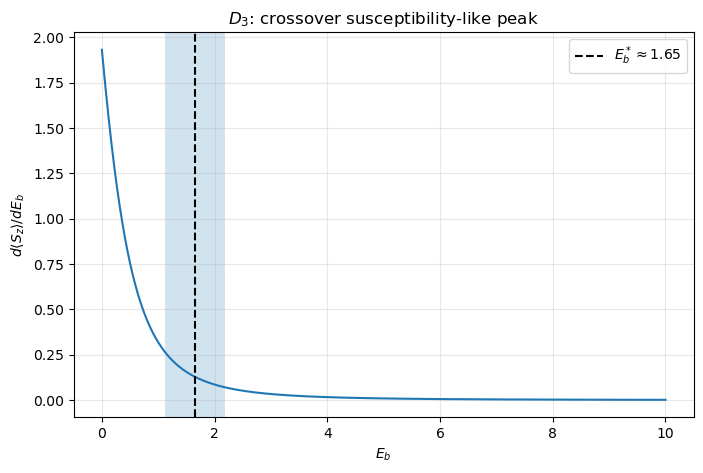

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# D3 symmetry: field analysis
# =========================

sqrt = np.sqrt

# =========================
# Stevens / crystal-field parameters
# Replace these with your D3 values
# =========================

# If your Maple notation calls this B00, keep B00.
# I am setting B00 = B20 for compatibility with your D3 matrix.
B00 = 0.0      # equivalent to B_2^0 if that is your convention
B40 = -0.04117266
B43 = -0.2058633     # replace with your D3 B_4^3 value

S = 5/2

# Basis ordering:
# |5/2>, |1/2>, |-3/2>, |-5/2>, |-1/2>, |3/2>
m_vals = np.array([5/2, 1/2, -1/2, 3/2, -5/2, -3/2], dtype=float)
Sz = np.diag(m_vals)

# =========================
# D3 Hamiltonian
# =========================

H_D3 = np.array([
    [10*B00 - 60*B40,        0,                 0,                 0,  3*sqrt(10)*B43,                 0],
    [0,                    -8*B00 - 120*B40,    0,                 0,                 0,                 0],
    [0,                     0,                -2*B00 - 120*B40,    0,                 0,                 0],
    [0,                     0,                 0,                10*B00 - 60*B40,    0,                 0],
    [3*sqrt(10)*B43,         0,                 0,                 0, -8*B00 - 120*B40,                 0],
    [0,                     0,                 0,                 0,                 0, -2*B00 - 120*B40]
], dtype=float)

def H_D3_with_field(Eb):
    """
    Matrix-first treatment:
    include -Eb * Sz in the Hamiltonian before diagonalizing.
    """
    return H_D3 - Eb * Sz

def eig_D3(Eb):
    return np.linalg.eigvalsh(H_D3_with_field(Eb))

def eigh_D3(Eb):
    return np.linalg.eigh(H_D3_with_field(Eb))


# =========================
# Field grid
# =========================

Eb_grid = np.linspace(0, 10, 20000)

evals = []
ground_magnetization = []

for Eb in Eb_grid:
    w, v = eigh_D3(Eb)

    evals.append(w)

    psi0 = v[:, 0]
    mz0 = np.real(np.conj(psi0) @ Sz @ psi0)
    ground_magnetization.append(mz0)

evals = np.array(evals)
ground_magnetization = np.array(ground_magnetization)


# =========================
# Method 1:
# pseudo-critical field from maximum slope of <Sz>
# =========================

dM_dEb = np.gradient(ground_magnetization, Eb_grid)

# Ignore Eb = 0 because Kramers degeneracy can create artificial behavior there
mask = Eb_grid > 1.0

idx_peak = np.argmax(dM_dEb[mask])
idx_peak_global = np.where(mask)[0][idx_peak]

Eb_peak = Eb_grid[idx_peak_global]
chi_peak = dM_dEb[idx_peak_global]

print("Pseudo-critical field from max d<Sz>/dEb:")
print(f"Eb* = {Eb_peak:.6f}")
print(f"Peak d<Sz>/dEb = {chi_peak:.6f}")


# =========================
# Estimate crossover width
# Treat d<Sz>/dEb as a weighted distribution
# =========================

chi = np.clip(dM_dEb, 0, None)

threshold = 0.10 * np.max(chi[mask])
peak_region = mask & (chi > threshold)

Eb_mean = np.sum(Eb_grid[peak_region] * chi[peak_region]) / np.sum(chi[peak_region])
Eb_std = np.sqrt(
    np.sum((Eb_grid[peak_region] - Eb_mean)**2 * chi[peak_region])
    / np.sum(chi[peak_region])
)

print()
print("Weighted crossover estimate:")
print(f"Eb* = {Eb_mean:.6f} ± {Eb_std:.6f}")


# =========================
# FWHM estimate
# =========================

half_max = 0.5 * np.max(chi[mask])
fwhm_region = mask & (chi >= half_max)

Eb_fwhm_low = Eb_grid[fwhm_region][0]
Eb_fwhm_high = Eb_grid[fwhm_region][-1]
Eb_fwhm_center = 0.5 * (Eb_fwhm_low + Eb_fwhm_high)
Eb_fwhm_half_width = 0.5 * (Eb_fwhm_high - Eb_fwhm_low)

print()
print("FWHM crossover estimate:")
print(f"Eb* = {Eb_fwhm_center:.6f} ± {Eb_fwhm_half_width:.6f}")
print(f"FWHM range: [{Eb_fwhm_low:.6f}, {Eb_fwhm_high:.6f}]")


# =========================
# Plot 1: eigenvalues
# =========================

plt.figure(figsize=(8, 5))

for i in range(6):
    plt.plot(Eb_grid, evals[:, i], label=f"Level {i+1}")

plt.axvline(Eb_mean, color="k", linestyle="--", label=rf"$E_b^* \approx {Eb_mean:.2f}$")
plt.axvspan(Eb_mean - Eb_std, Eb_mean + Eb_std, alpha=0.2)

plt.xlabel(r"$E_b$")
plt.ylabel("Energy eigenvalue")
plt.title(r"$D_3$ symmetry: adiabatic eigenvalues vs field energy")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()


# =========================
# Plot 2: ground-state <Sz>
# =========================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, ground_magnetization)
plt.axvline(Eb_mean, color="k", linestyle="--", label=rf"$E_b^* \approx {Eb_mean:.2f}$")
plt.axvspan(Eb_mean - Eb_std, Eb_mean + Eb_std, alpha=0.2)

plt.xlabel(r"$E_b$")
plt.ylabel(r"$\langle S_z \rangle_{\mathrm{ground}}$")
plt.title(r"$D_3$: ground-state spin polarization vs field")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# =========================
# Plot 3: derivative peak
# =========================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, dM_dEb)
plt.axvline(Eb_mean, color="k", linestyle="--", label=rf"$E_b^* \approx {Eb_mean:.2f}$")
plt.axvspan(Eb_mean - Eb_std, Eb_mean + Eb_std, alpha=0.2)

plt.xlabel(r"$E_b$")
plt.ylabel(r"$d\langle S_z \rangle / dE_b$")
plt.title(r"$D_3$: crossover susceptibility-like peak")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [20]:
# =========================
# D2 heat capacity matching Maple rendition
# C = d² ln(Z) / dβ², then β = 1/T
# =========================

import plotly.graph_objects as go

T_grid = np.linspace(0, 10, 250)
Eb_grid_heat = np.linspace(0, 40, 250)

C_grid_maple = np.zeros((len(T_grid), len(Eb_grid_heat)))

for j, Eb in enumerate(Eb_grid_heat):
    E = eig_D3(Eb)

    # optional stability shift; does not change C_beta
    E = E - np.min(E)

    for i, T in enumerate(T_grid):
        beta = 1 / T

        weights = np.exp(-beta * E)
        Z = np.sum(weights)

        E_avg = np.sum(E * weights) / Z
        E3_avg = np.sum(E**2 * weights) / Z

        # Maple: diff(diff(ln(Z), beta), beta)
        C_grid_maple[i, j] = E3_avg - E_avg**2

Eb_mesh, T_mesh = np.meshgrid(Eb_grid_heat, T_grid)

fig = go.Figure(data=[
    go.Surface(
        x=T_mesh,
        y=Eb_mesh,
        z=C_grid_maple,
        colorscale="Viridis",
        colorbar=dict(title="Capacity")
    )
])

fig.update_layout(
    title="D3: C(T, Eb) Matching Maple Form",
    scene=dict(
        xaxis_title="Temperature",
        yaxis_title="Energy",
        zaxis_title="Capacity"
    ),
    width=850,
    height=650
)

fig.show()

In [24]:
# =========================
# D3 heat capacity / Maple form contour plot
# C = d² ln(Z) / dβ² = <E²> - <E>²
# β = 1/T
# =========================

import numpy as np
import plotly.graph_objects as go

T_grid = np.linspace(0.1, 10, 250)       # avoid T = 0
Eb_grid_heat = np.linspace(0, 40, 250)

C_grid_maple = np.zeros((len(T_grid), len(Eb_grid_heat)))

for j, Eb in enumerate(Eb_grid_heat):
    E = eig_D3(Eb)

    # Stability shift; does not change variance
    E = E - np.min(E)

    for i, T in enumerate(T_grid):
        beta = 1 / T

        weights = np.exp(-beta * E)
        Z = np.sum(weights)

        E_avg = np.sum(E * weights) / Z
        E2_avg = np.sum(E**2 * weights) / Z

        # Maple: d² ln(Z) / dβ² = <E²> - <E>²
        C_grid_maple[i, j] = E2_avg - E_avg**2


# =========================
# Above-view contour plot
# =========================

fig = go.Figure(data=[
    go.Contour(
        x=Eb_grid_heat,
        y=T_grid,
        z=C_grid_maple,
        colorscale="Viridis",
        colorbar=dict(title="Capacity"),
        contours=dict(
            coloring="heatmap",
            showlines=True
        )
    )
])

fig.update_layout(
    title="D3: Above-View Contour Plot of C(T, Eb), Maple Form",
    xaxis_title=r"Field Energy $E_b$",
    yaxis_title=r"Temperature $T$",
    width=850,
    height=650
)

fig.show()

In [2]:
import numpy as np
import plotly.graph_objects as go

sqrt = np.sqrt

# ============================================================
# Enter specific D4 Stevens parameters here
# Optimization target:
# 3 B20 ≈ 60 B40, with small nonzero B44
# ============================================================

B20 = 1.0
B40 = 0.048      # not exact cancellation
B44 = 0.02

# ============================================================
# D4 Hamiltonian and eigenvalues
# Basis:
# |5/2>, |1/2>, |-3/2>, |-5/2>, |-1/2>, |3/2>
# ============================================================

m_vals_D4 = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)
Sz_D4 = np.diag(m_vals_D4)

def H_D4_from_params(B20, B40, B44):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 + 180*B40
    C = 12*np.sqrt(5)*B44

    block = np.array([
        [A, 0, C],
        [0, D, 0],
        [C, 0, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block

    return H

H0_D4 = H_D4_from_params(B20, B40, B44)

def eig_D4(Eb):
    H = H0_D4 - Eb * Sz_D4
    return np.linalg.eigvalsh(H)

# ============================================================
# Analytic estimates
# ============================================================

Eb_cross_D4_1 = 3*B20 - 60*B40
Eb_cross_D4_2 = -3*B20 + 60*B40
gap_D4 = 24*np.sqrt(5)*abs(B44)

print("D4 analytic estimates:")
print(f"B20 = {B20}")
print(f"B40 = {B40}")
print(f"B44 = {B44}")
print(f"Eb^(0,1) = {Eb_cross_D4_1:.6f}")
print(f"Eb^(0,2) = {Eb_cross_D4_2:.6f}")
print(f"Δ_min = {gap_D4:.6f}")

# ============================================================
# Heat-capacity / Maple-form contour grid
# ============================================================

T_grid = np.linspace(0.01, 5, 300)
Eb_grid_heat = np.linspace(0, 5, 300)

C_grid_maple = np.zeros((len(T_grid), len(Eb_grid_heat)))

for j, Eb in enumerate(Eb_grid_heat):
    E = eig_D4(Eb)
    E = E - np.min(E)

    for i, T in enumerate(T_grid):
        beta = 1 / T

        weights = np.exp(-beta * E)
        Z = np.sum(weights)

        E_avg = np.sum(E * weights) / Z
        E2_avg = np.sum(E**2 * weights) / Z

        C_grid_maple[i, j] = E2_avg - E_avg**2

# ============================================================
# Contour plot
# ============================================================

fig = go.Figure(data=[
    go.Contour(
        x=Eb_grid_heat,
        y=T_grid,
        z=C_grid_maple,
        colorscale="Viridis",
        colorbar=dict(title=r"$\langle E^2\rangle-\langle E\rangle^2$"),
        contours=dict(
            coloring="heatmap",
            showlines=True
        )
    )
])

fig.add_vline(
    x=Eb_cross_D4_1,
    line_dash="dash",
    line_color="white",
    annotation_text=r"$E_b^{(0)}$",
    annotation_position="top"
)

fig.update_layout(
    title=(
        "D4 Heat-Capacity Contour near Optimized Stevens Condition: "
        f"B20={B20}, B40={B40}, B44={B44}"
    ),
    xaxis_title=r"Field Energy $E_b$",
    yaxis_title=r"Temperature $T$",
    width=850,
    height=650
)

fig.show()

D4 analytic estimates:
B20 = 1.0
B40 = 0.048
B44 = 0.02
Eb^(0,1) = 0.120000
Eb^(0,2) = -0.120000
Δ_min = 1.073313


D4 diagnostics:
Analytic bare crossing Eb^(0,1) = 0.120000
Numerical peak in |d<Sz>/dEb| = 0.008402
Minimum ground-state gap at Eb = 0.000000
Minimum gap = 0.000000


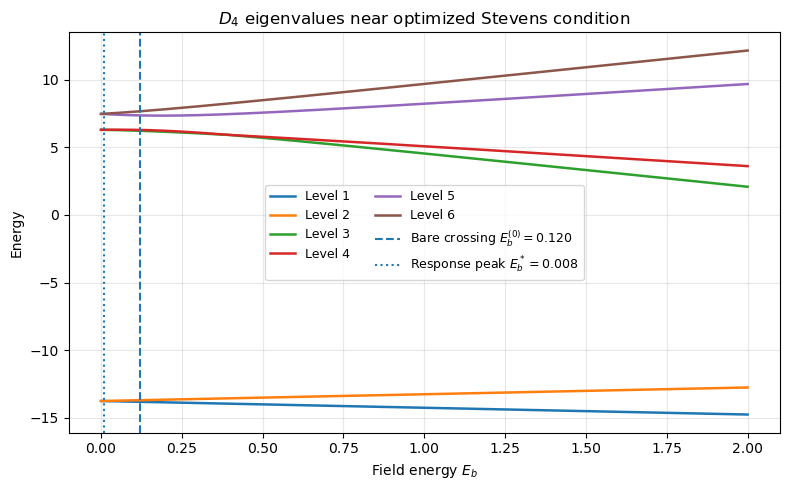

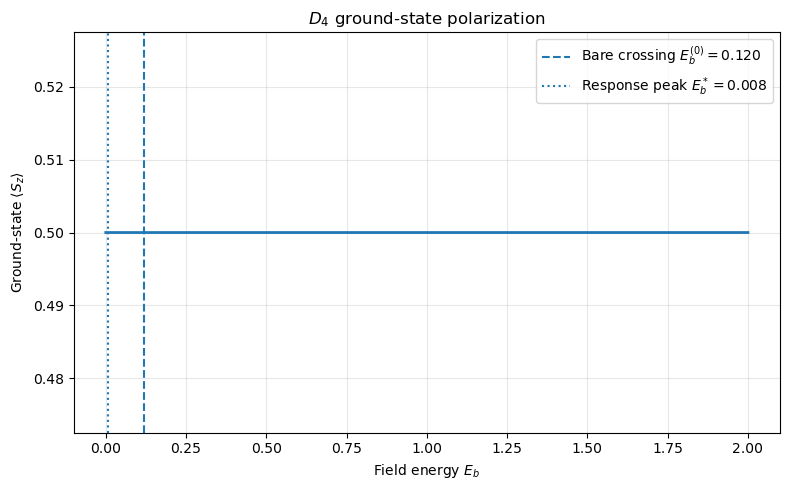

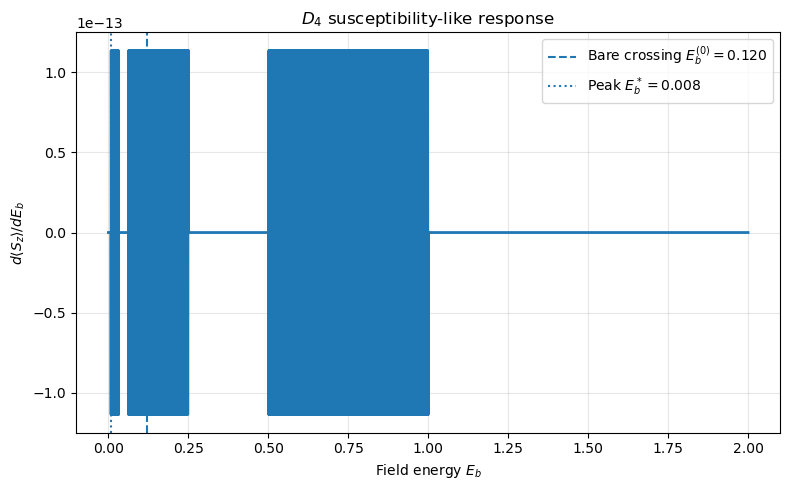

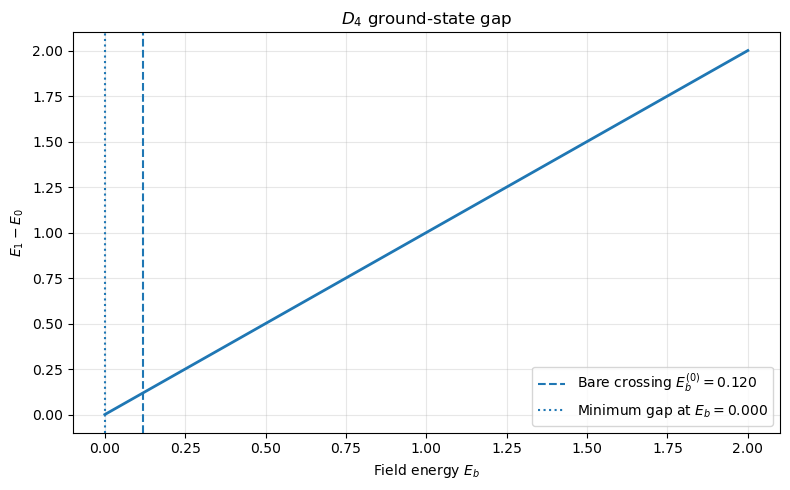

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# D4 transition diagnostics
# ============================================================

Eb_grid = np.linspace(0, 2.0, 5000)

evals = []
ground_mz = []
gaps = []

for Eb in Eb_grid:
    H = H0_D4 - Eb * Sz_D4
    w, v = np.linalg.eigh(H)

    evals.append(w)

    psi0 = v[:, 0]
    mz0 = np.real(np.conj(psi0) @ Sz_D4 @ psi0)
    ground_mz.append(mz0)

    gaps.append(w[1] - w[0])

evals = np.array(evals)
ground_mz = np.array(ground_mz)
gaps = np.array(gaps)

dM_dEb = np.gradient(ground_mz, Eb_grid)

# Locate strongest response peak
idx_peak = np.argmax(np.abs(dM_dEb))
Eb_star = Eb_grid[idx_peak]

# Locate minimum ground-state gap
idx_gap = np.argmin(gaps)
Eb_gap_min = Eb_grid[idx_gap]
gap_min = gaps[idx_gap]

print("D4 diagnostics:")
print(f"Analytic bare crossing Eb^(0,1) = {Eb_cross_D4_1:.6f}")
print(f"Numerical peak in |d<Sz>/dEb| = {Eb_star:.6f}")
print(f"Minimum ground-state gap at Eb = {Eb_gap_min:.6f}")
print(f"Minimum gap = {gap_min:.6f}")

# ============================================================
# Plot 1: Eigenvalues vs Eb
# ============================================================

plt.figure(figsize=(8, 5))

for i in range(6):
    plt.plot(Eb_grid, evals[:, i], linewidth=1.8, label=f"Level {i+1}")

plt.axvline(Eb_cross_D4_1, linestyle="--", label=rf"Bare crossing $E_b^{{(0)}}={Eb_cross_D4_1:.3f}$")
plt.axvline(Eb_star, linestyle=":", label=rf"Response peak $E_b^*={Eb_star:.3f}$")

plt.xlabel(r"Field energy $E_b$")
plt.ylabel("Energy")
plt.title(r"$D_4$ eigenvalues near optimized Stevens condition")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ground-state <Sz>
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, ground_mz, linewidth=2)
plt.axvline(Eb_cross_D4_1, linestyle="--", label=rf"Bare crossing $E_b^{{(0)}}={Eb_cross_D4_1:.3f}$")
plt.axvline(Eb_star, linestyle=":", label=rf"Response peak $E_b^*={Eb_star:.3f}$")

plt.xlabel(r"Field energy $E_b$")
plt.ylabel(r"Ground-state $\langle S_z\rangle$")
plt.title(r"$D_4$ ground-state polarization")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: d<Sz>/dEb
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, dM_dEb, linewidth=2)
plt.axvline(Eb_cross_D4_1, linestyle="--", label=rf"Bare crossing $E_b^{{(0)}}={Eb_cross_D4_1:.3f}$")
plt.axvline(Eb_star, linestyle=":", label=rf"Peak $E_b^*={Eb_star:.3f}$")

plt.xlabel(r"Field energy $E_b$")
plt.ylabel(r"$d\langle S_z\rangle/dE_b$")
plt.title(r"$D_4$ susceptibility-like response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: Ground-state gap
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, gaps, linewidth=2)
plt.axvline(Eb_cross_D4_1, linestyle="--", label=rf"Bare crossing $E_b^{{(0)}}={Eb_cross_D4_1:.3f}$")
plt.axvline(Eb_gap_min, linestyle=":", label=rf"Minimum gap at $E_b={Eb_gap_min:.3f}$")

plt.xlabel(r"Field energy $E_b$")
plt.ylabel(r"$E_1-E_0$")
plt.title(r"$D_4$ ground-state gap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
print(evals[:,0].min(), evals[:,1].min())

-14.759999999999998 -13.759999999999998


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

sqrt = np.sqrt

# ============================================================
# D4 Hamiltonian
# ============================================================

m_vals_D4 = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)
Sz_D4 = np.diag(m_vals_D4)

def H_D4_from_params(B20, B40, B44):
    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 + 180*B40
    C = 12*np.sqrt(5)*B44

    block = np.array([
        [A, 0, C],
        [0, D, 0],
        [C, 0, F],
    ], dtype=float)

    H = np.zeros((6, 6), dtype=float)
    H[:3, :3] = block
    H[3:, 3:] = block

    return H

def eig_D4_params(Eb, B20, B40, B44):
    H0 = H_D4_from_params(B20, B40, B44)
    H = H0 - Eb * Sz_D4
    return np.linalg.eigvalsh(H)

def transition_score_D4(B20, B40, B44, Eb_min=0, Eb_max=5, n_Eb=1000):
    """
    Finds whether there is a ground-state transition/crossover.
    Good transition = small ground-state gap at finite field.
    """
    Eb_grid = np.linspace(Eb_min, Eb_max, n_Eb)

    gaps = []
    evals_all = []

    for Eb in Eb_grid:
        w = eig_D4_params(Eb, B20, B40, B44)
        evals_all.append(w)
        gaps.append(w[1] - w[0])

    evals_all = np.array(evals_all)
    gaps = np.array(gaps)

    idx = np.argmin(gaps)

    Eb_star = Eb_grid[idx]
    min_gap = gaps[idx]

    # Check if minimum is not just at the boundary
    boundary_flag = (
        idx == 0 or idx == len(Eb_grid)-1
    )

    return {
        "B20": B20,
        "B40": B40,
        "B44": B44,
        "Eb_star": Eb_star,
        "min_ground_gap": min_gap,
        "boundary_flag": boundary_flag,
        "E0_at_star": evals_all[idx, 0],
        "E1_at_star": evals_all[idx, 1],
    }

In [6]:
# ============================================================
# Parameter scan
# ============================================================

B20_vals = np.linspace(-3, 3, 121)
B40_vals = np.linspace(-0.2, 0.2, 121)

# Small nonzero B44 gives a sharp but finite avoided crossing
B44_fixed = 0.01

scan_rows = []

for B20 in tqdm(B20_vals):
    for B40 in B40_vals:
        scan_rows.append(
            transition_score_D4(
                B20=B20,
                B40=B40,
                B44=B44_fixed,
                Eb_min=0,
                Eb_max=5,
                n_Eb=800
            )
        )

scan_df = pd.DataFrame(scan_rows)

# Keep only finite-field, non-boundary transitions
good_df = scan_df[
    (~scan_df["boundary_flag"]) &
    (scan_df["Eb_star"] > 0.02)
].copy()

# Sort by smallest ground-state gap
good_df = good_df.sort_values("min_ground_gap")

display(good_df.head(20))

100%|██████████| 121/121 [00:58<00:00,  2.06it/s]


,B20,B40,B44,Eb_star,min_ground_gap,boundary_flag,E0_at_star,E1_at_star


In [7]:
best = good_df.iloc[0]

B20_best = best["B20"]
B40_best = best["B40"]
B44_best = best["B44"]

print("Best ground-state transition candidate:")
print(best)

Eb_grid = np.linspace(0, 5, 3000)

evals = []
ground_mz = []
gaps = []

H0 = H_D4_from_params(B20_best, B40_best, B44_best)

for Eb in Eb_grid:
    H = H0 - Eb * Sz_D4
    w, v = np.linalg.eigh(H)

    evals.append(w)

    psi0 = v[:, 0]
    mz = np.real(np.conj(psi0) @ Sz_D4 @ psi0)
    ground_mz.append(mz)

    gaps.append(w[1] - w[0])

evals = np.array(evals)
ground_mz = np.array(ground_mz)
gaps = np.array(gaps)

dM_dEb = np.gradient(ground_mz, Eb_grid)

idx_gap = np.argmin(gaps)
Eb_gap = Eb_grid[idx_gap]

idx_peak = np.argmax(np.abs(dM_dEb))
Eb_peak = Eb_grid[idx_peak]

print(f"Minimum gap at Eb = {Eb_gap:.6f}")
print(f"Peak response at Eb = {Eb_peak:.6f}")
print(f"Minimum gap = {gaps[idx_gap]:.6e}")

IndexError: single positional indexer is out-of-bounds